<a href="https://colab.research.google.com/github/UNIVERSALIONZ/Pipeline-1/blob/main/Training%20Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

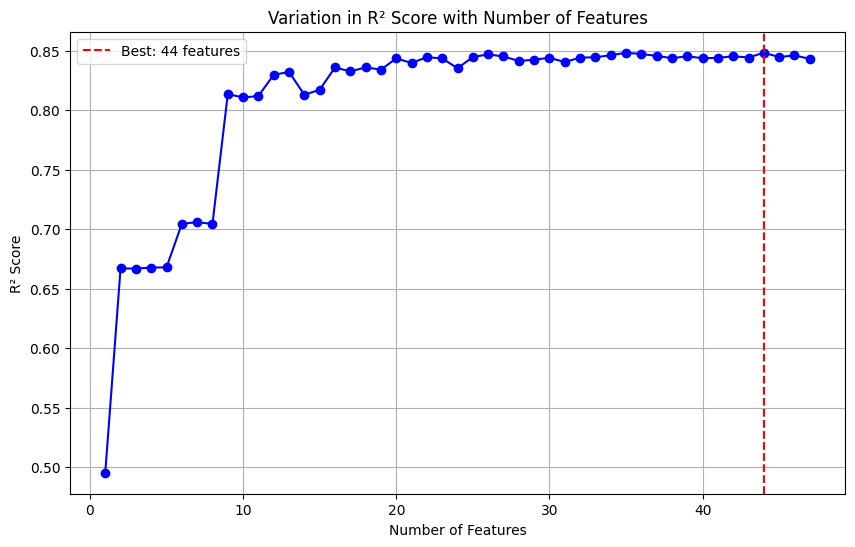

Best R² Score: 0.8481 achieved with 44 features.
Selected features saved as 'top_selected_features.csv'.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Load dataset
file_path = "Features_all_new.csv"  # Update with your file path
data = pd.read_csv(file_path)

# Define features and target
X = data.drop(columns=["Protein_name", "Binding_affinity"])  # Exclude non-numeric columns
y = data["Binding_affinity"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model to get feature importances
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Get feature importances
feature_importances = model.feature_importances_
feature_names = X.columns

# Rank features by importance
sorted_indices = np.argsort(feature_importances)[::-1]
sorted_features = feature_names[sorted_indices]
sorted_importances = feature_importances[sorted_indices]

# Track R² scores as features are added
r2_scores = []
selected_features = []
best_r2 = 0
best_feature_count = 0

for i in range(1, len(sorted_features) + 1):
    # Use top i features
    X_train_subset = X_train[sorted_features[:i]]
    X_test_subset = X_test[sorted_features[:i]]

    # Train model with selected features
    model.fit(X_train_subset, y_train)
    y_pred = model.predict(X_test_subset)

    # Compute R² score
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)
    selected_features.append(sorted_features[:i])

    # Store best feature count
    if r2 > best_r2:
        best_r2 = r2
        best_feature_count = i

# Plot R² score vs. number of features
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(sorted_features) + 1), r2_scores, marker="o", linestyle="-", color="b")
plt.axvline(x=best_feature_count, color="r", linestyle="--", label=f"Best: {best_feature_count} features")
plt.xlabel("Number of Features")
plt.ylabel("R² Score")
plt.title("Variation in R² Score with Number of Features")
plt.legend()
plt.grid()
plt.savefig("feature_selection_r2_plot3_134.png", dpi=300)
plt.show()

# Save the best selected features
optimal_features = selected_features[best_feature_count - 1]  # Features at best R²
selected_data = data[["Protein_name", "Binding_affinity"] + list(optimal_features)]
selected_data.to_csv("top_selected_features_rfa3_134.csv", index=False)

print(f"Best R² Score: {best_r2:.4f} achieved with {best_feature_count} features.")
print(f"Selected features saved as 'top_selected_features.csv'.")

[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=4. Current value: min_data_in_leaf=4
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=4. Current value: min_data_in_leaf=4
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000541 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3581
[LightGBM] [Info] Number of data points in the train set: 390, number of used features: 44
[LightGBM] [Info] Start training from score -7.205590


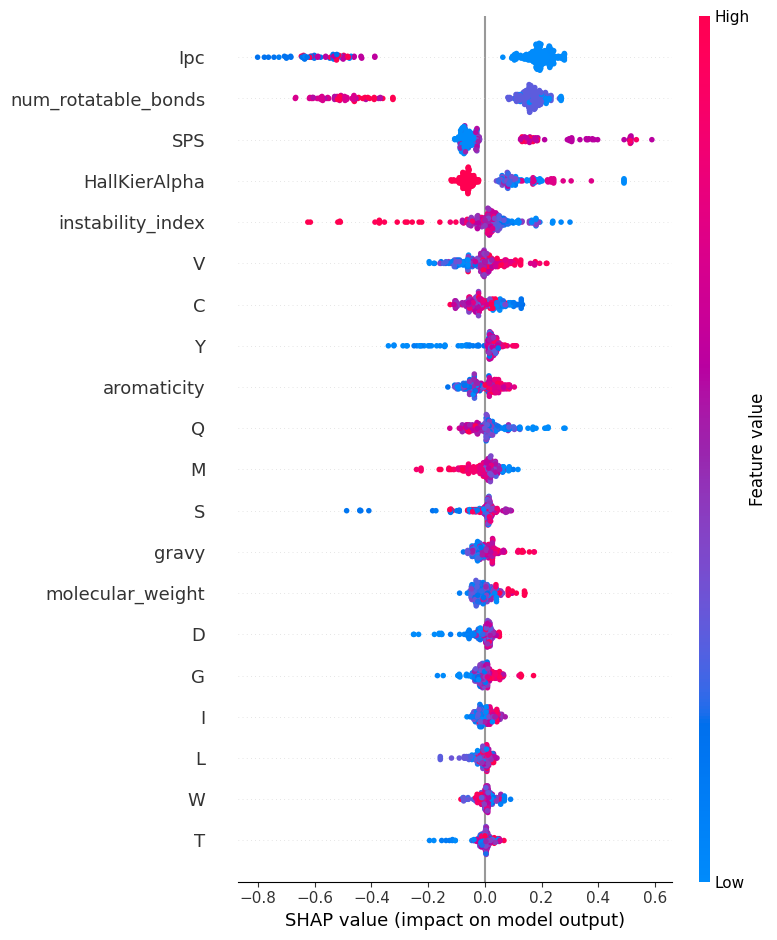

In [ ]:
import shap
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("top_selected_features_rfa3_134.csv")  # 77 features + activity column

# Define features and target
X = df.drop(columns=["Protein_name", "Binding_affinity"])  # Exclude non-numeric columns
y = df["Binding_affinity"]

# Split into train and validation sets (40% test size as per your previous setup)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.4, random_state=42)

# Train LightGBM model
lgbm = lgb.LGBMRegressor(n_estimators=200, max_depth=20, min_samples_leaf=4, min_samples_split=2, random_state=42)
lgbm.fit(X_train, y_train)

# Compute SHAP values
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer(X_val)

# SHAP Summary Plot (Shows feature importance)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_val)

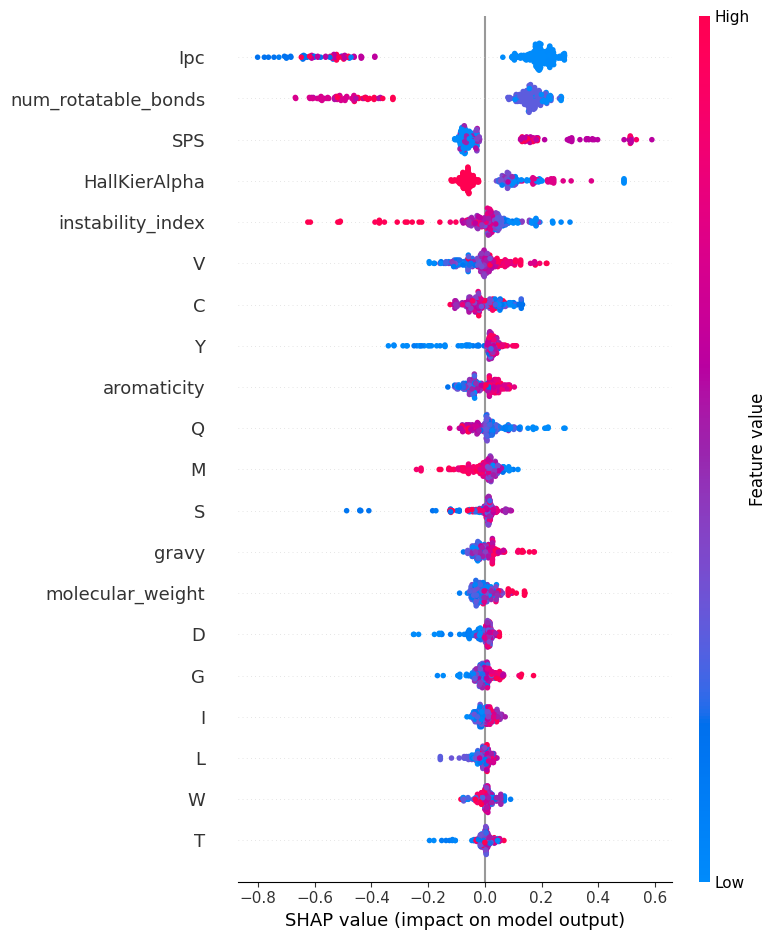

In [ ]:
shap.summary_plot(shap_values.values, X_val, feature_names=X_val.columns)

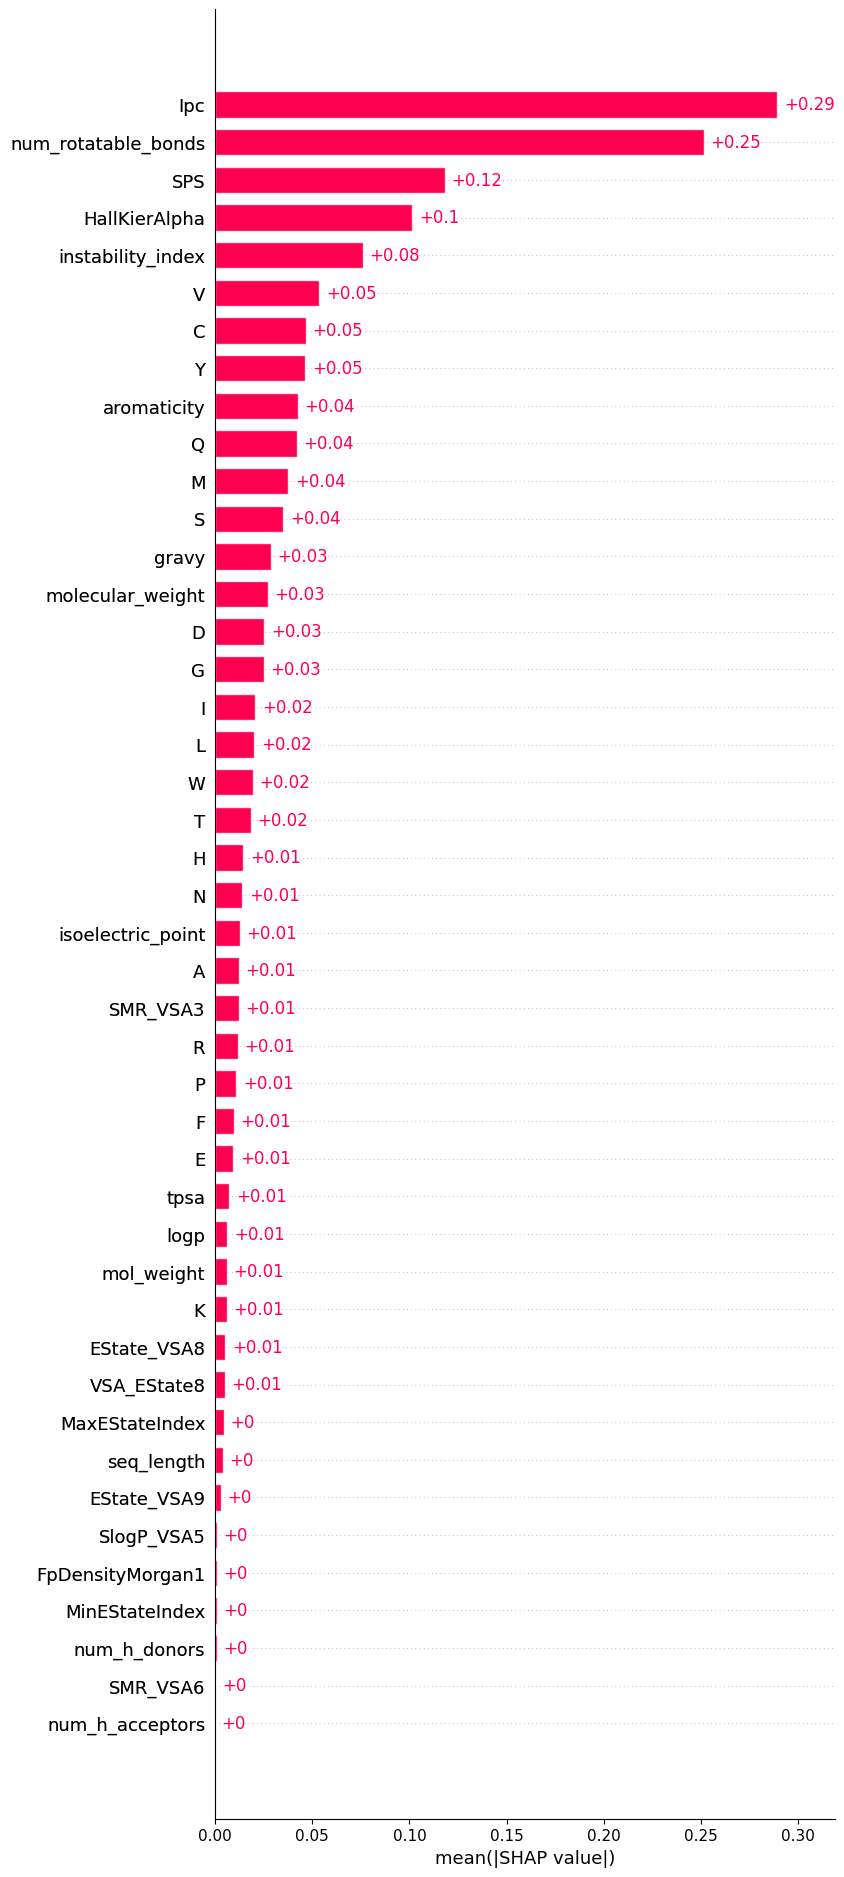

In [ ]:
shap.plots.bar(shap_values, max_display=44)  # Display all 80 features

In [ ]:
import numpy as np
import pandas as pd

# Get SHAP mean absolute values for each feature
shap_importance = np.abs(shap_values.values).mean(axis=0)

# Get feature names from your dataset
feature_names = X_val.columns

# Filter only non-zero SHAP contribution features
important_features = feature_names[shap_importance > 0]

# Save selected features to a CSV
important_features_df = pd.DataFrame(important_features, columns=["Feature"])
important_features_df.to_csv("important_features_44.csv", index=False)

print(f"Saved {len(important_features)} important features to 'important_features_44.csv'.")

Saved 44 important features to 'important_features_44.csv'.


🔍 Performing Randomized Search...
🔍 Performing Grid Search for Fine-tuning...


/home/sudipta/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/sudipta/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/sudipta/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/sudipta/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/sudipta/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined wit

✅ Model training and validation complete!
R² Training: 0.9624
R² Test: 0.8467
MAE Training: 0.0990
MAE Test: 0.1998
RMSE Training: 0.1645
RMSE Test: 0.3289
Standard Deviation Training: 0.1645
Standard Deviation Test: 0.3289
Cross-validation R² (10-Fold): 0.7873
Leave-One-Out R²: nan
Jackknife R²: 0.7985



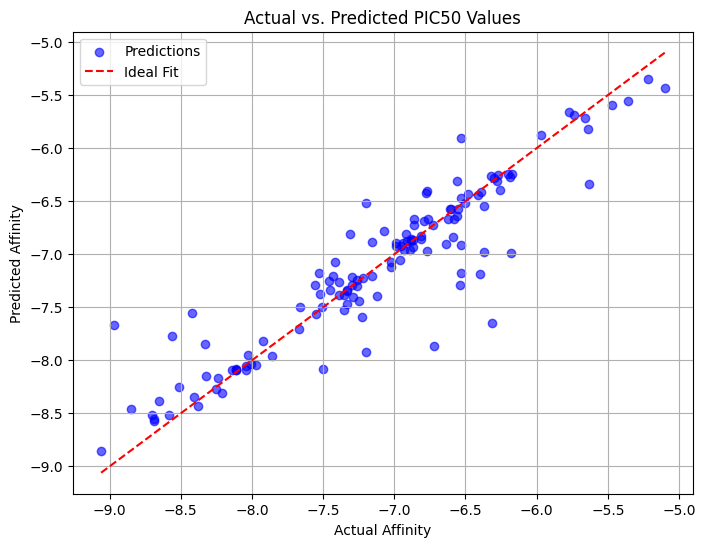

In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, cross_val_score, LeaveOneOut
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1️⃣ Load dataset
file_path = "top_selected_features_44.csv"  # Replace with actual dataset path
data = pd.read_csv(file_path)

# 2️⃣ Define features and target
X = data.drop(columns=["Protein_name", "Binding_affinity"])  # Drop non-numeric columns
y = data["Binding_affinity"]

# 3️⃣ Split dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4️⃣ Define Random Forest model
rf_model = RandomForestRegressor(random_state=42)

# 5️⃣ Define hyperparameter search space
param_grid = {
    "n_estimators": [100, 200, 500],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# 6️⃣ Hyperparameter tuning
print("🔍 Performing Randomized Search...")
random_search = RandomizedSearchCV(rf_model, param_grid, n_iter=10, cv=10, scoring="r2", n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)

print("🔍 Performing Grid Search for Fine-tuning...")
grid_search = GridSearchCV(rf_model, param_grid, cv=10, scoring="r2", n_jobs=-1)
grid_search.fit(X_train, y_train)

# Select the best model
best_rf_model = grid_search.best_estimator_

# 7️⃣ Evaluate model on Test Set
y_pred_train = best_rf_model.predict(X_train)
y_pred_test = best_rf_model.predict(X_test)

# Calculate metrics
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

train_std = np.std(y_train - y_pred_train)
test_std = np.std(y_test - y_pred_test)

# 8️⃣ Cross-validation (10-Fold CV)
cv_scores = cross_val_score(best_rf_model, X_train, y_train, cv=10, scoring="r2")
cv_r2_mean = cv_scores.mean()

# 9️⃣ Leave-One-Out Cross-Validation (LOO)
loo = LeaveOneOut()
loo_scores = cross_val_score(best_rf_model, X_train, y_train, cv=loo, scoring="r2")
loo_r2_mean = loo_scores.mean()

# 🔟 Jackknife (Resampling Method)
jackknife_scores = []
for i in range(len(y_train)):
    X_jackknife = np.delete(X_train.to_numpy(), i, axis=0)
    y_jackknife = np.delete(y_train.to_numpy(), i)

    model = RandomForestRegressor(random_state=42)
    model.fit(X_jackknife, y_jackknife)
    y_pred_jackknife = model.predict(X_train.iloc[[i]])[0]
    jackknife_scores.append(y_train.iloc[i] - y_pred_jackknife)

jackknife_r2 = 1 - (np.var(jackknife_scores) / np.var(y_train))

# 📊 Save Results
metrics_text = (
    f"R² Training: {train_r2:.4f}\n"
    f"R² Test: {test_r2:.4f}\n"
    f"MAE Training: {train_mae:.4f}\n"
    f"MAE Test: {test_mae:.4f}\n"
    f"RMSE Training: {train_rmse:.4f}\n"
    f"RMSE Test: {test_rmse:.4f}\n"
    f"Standard Deviation Training: {train_std:.4f}\n"
    f"Standard Deviation Test: {test_std:.4f}\n"
    f"Cross-validation R² (10-Fold): {cv_r2_mean:.4f}\n"
    f"Leave-One-Out R²: {loo_r2_mean:.4f}\n"
    f"Jackknife R²: {jackknife_r2:.4f}\n"
)

with open("metrics_RF.txt", "w") as file:
    file.write(metrics_text)

# 📈 Save test predictions
test_results = pd.DataFrame({"Actual_Affinity": y_test, "Predicted_Affinity": y_pred_test})
test_results.to_csv("test_set_predictions_RF_44_final.csv", index=False)

# 💾 Save model
joblib.dump(best_rf_model, "random_forest_model_44_final.pkl")

print("✅ Model training and validation complete!")
print(metrics_text)

# 📊 Visualization
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, color="blue", alpha=0.6, label="Predictions")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color="red", linestyle="dashed", label="Ideal Fit")
plt.xlabel("Actual Affinity")
plt.ylabel("Predicted Affinity")
plt.title("Actual vs. Predicted PIC50 Values")
plt.legend()
plt.grid()
plt.savefig("RF_PIC50_Plot_44_final.png", dpi=300)
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# 1. Load the data from a .csv file
data = pd.read_csv('top_selected_features_44.csv')

# 2. Define features and target variable
X = data.drop(columns=["Protein_name", "Binding_affinity"])
y = data["Binding_affinity"]

# 3. Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

# 4. Train the Random Forest model with the training set
rf_model = RandomForestRegressor(random_state=11)
rf_model.fit(X_train, y_train)

# 5. Evaluate the model's performance
# a. R^2 coefficient of determination
train_r2 = r2_score(y_train, rf_model.predict(X_train))
test_r2 = r2_score(y_test, rf_model.predict(X_test))

# b. Mean absolute error (MAE)
train_mae = mean_absolute_error(y_train, rf_model.predict(X_train))
test_mae = mean_absolute_error(y_test, rf_model.predict(X_test))

# c. Standard deviation
train_std = np.std(y_train - rf_model.predict(X_train))
test_std = np.std(y_test - rf_model.predict(X_test))

# d. Root mean squared error (RMSE)
train_rmse = np.sqrt(mean_squared_error(y_train, rf_model.predict(X_train)))
test_rmse = np.sqrt(mean_squared_error(y_test, rf_model.predict(X_test)))

# 6. Prepare the metrics text
metrics_text = (
    f"R2 Training: {train_r2}\n"
    f"R2 Test: {test_r2}\n"
    f"MAE Training: {train_mae}\n"
    f"MAE Test: {test_mae}\n"
    f"Standard Deviation Training: {train_std}\n"
    f"Standard Deviation Test: {test_std}\n"
    f"RMSE Training: {train_rmse}\n"
    f"RMSE Test: {test_rmse}\n"
)

# 7. Write the metrics to a .txt file
with open('metrics_RF_97_final_lit.txt', 'w') as file:
    file.write(metrics_text)

# 8. Generate predicted values
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# 9. Create dataframes for training and test sets with actual and predicted values
train_results = pd.DataFrame({
    'Y_Train_Actual': y_train,
    'Y_Train_Predicted': y_train_pred
})

test_results = pd.DataFrame({
    'Y_Test_Actual': y_test,
    'Y_Test_Predicted': y_test_pred
})

# 10. Combine the training and test results into a single dataframe
combined_results = pd.concat([train_results.reset_index(drop=True), test_results.reset_index(drop=True)], axis=1)
print("✅ SVR Model Training Complete!")
print(metrics_text)
# 11. Export the combined dataframe
combined_results.to_csv('XY_RF_97_final_lit.csv', sep=';', index=False)

✅ SVR Model Training Complete!
R2 Training: 0.9575407091165888
R2 Test: 0.7882374830469843
MAE Training: 0.1038817811963674
MAE Test: 0.22974150426709966
Standard Deviation Training: 0.17466883390175084
Standard Deviation Test: 0.3892661665786408
RMSE Training: 0.17466890847226535
RMSE Test: 0.38938480795867436



✅ SVR Model Training Complete!
R2 Training: 0.9388448090477776
R2 Test: 0.7885730977343739
MAE Training: 0.14988782775842968
MAE Test: 0.24360850183728283
Standard Deviation Training: 0.2096263638695286
Standard Deviation Test: 0.38907587420936124
RMSE Training: 0.2096263638695286
RMSE Test: 0.38907612471686825



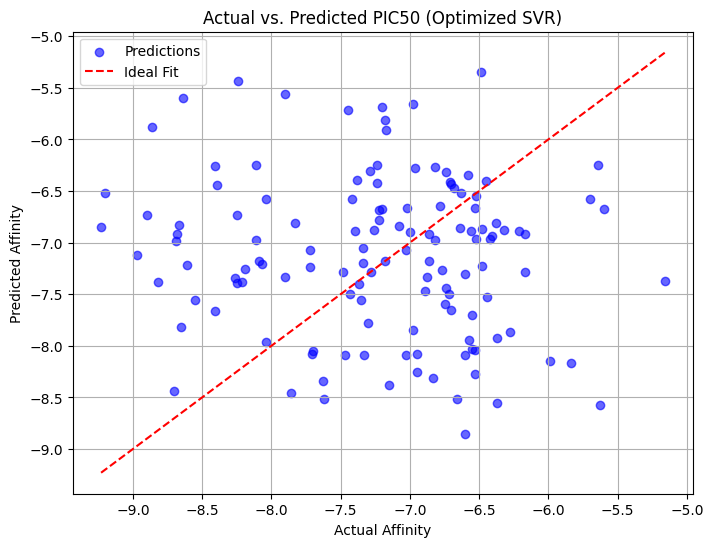

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# 1. Load the data from a .csv file
data = pd.read_csv('top_selected_features_44.csv')

# 2. Define features and target variable
X = data.drop(columns=["Protein_name", "Binding_affinity"])
y = data["Binding_affinity"]

# 3. Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

# 4. Train the Gradient Boosting model with the training set
gb_model = GradientBoostingRegressor(random_state=11)
gb_model.fit(X_train, y_train)

# 5. Evaluate the model's performance
train_r2 = r2_score(y_train, gb_model.predict(X_train))
test_r2 = r2_score(y_test, gb_model.predict(X_test))

train_mae = mean_absolute_error(y_train, gb_model.predict(X_train))
test_mae = mean_absolute_error(y_test, gb_model.predict(X_test))

train_std = np.std(y_train - gb_model.predict(X_train))
test_std = np.std(y_test - gb_model.predict(X_test))

train_rmse = np.sqrt(mean_squared_error(y_train, gb_model.predict(X_train)))
test_rmse = np.sqrt(mean_squared_error(y_test, gb_model.predict(X_test)))

# 6. Prepare the metrics text
metrics_text = (
    f"R2 Training: {train_r2}\n"
    f"R2 Test: {test_r2}\n"
    f"MAE Training: {train_mae}\n"
    f"MAE Test: {test_mae}\n"
    f"Standard Deviation Training: {train_std}\n"
    f"Standard Deviation Test: {test_std}\n"
    f"RMSE Training: {train_rmse}\n"
    f"RMSE Test: {test_rmse}\n"
)

# 7. Write the metrics to a .txt file
with open('metrics_GB_97_final_lit.txt', 'w') as file:
    file.write(metrics_text)

# 8. Generate predicted values
y_train_pred = gb_model.predict(X_train)
y_test_pred = gb_model.predict(X_test)

# 9. Create dataframes for training and test sets with actual and predicted values
train_results = pd.DataFrame({
    'Y_Train_Actual': y_train,
    'Y_Train_Predicted': y_train_pred
})

test_results = pd.DataFrame({
    'Y_Test_Actual': y_test,
    'Y_Test_Predicted': y_test_pred
})

# 10. Combine the training and test results into a single dataframe
combined_results = pd.concat([train_results.reset_index(drop=True), test_results.reset_index(drop=True)], axis=1)

# 11. Export the combined dataframe
combined_results.to_csv('XY_GB_97_final_lit.csv', sep=';', index=False)
print("✅ SVR Model Training Complete!")
print(metrics_text)
# 📈 Visualization
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, color="blue", alpha=0.6, label="Predictions")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color="red", linestyle="dashed", label="Ideal Fit")
plt.xlabel("Actual Affinity")
plt.ylabel("Predicted Affinity")
plt.title("Actual vs. Predicted PIC50 (Optimized SVR)")
plt.legend()
plt.grid()
plt.savefig("GBM_PIC50_Plot_Optimized_97_final_lit.png", dpi=300)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import joblib
import time
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import r2_score

# Load dataset
file_path = "top_selected_features_44.csv"
data = pd.read_csv(file_path)

# Define features and target
X = data.drop(columns=["Protein_name", "Binding_affinity"])
y = data["Binding_affinity"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define GBR model
gbr_model = GradientBoostingRegressor(random_state=42)

# Hyperparameter search space
param_grid = {
    "n_estimators": [100, 200, 500],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, 10]
}

# Progress tracking
print("🔍 Performing Grid Search for GBR...")
start_time = time.time()

# Grid Search
grid_search = GridSearchCV(gbr_model, param_grid, cv=10, scoring="r2", n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# Best GBR model
best_gbr_model = grid_search.best_estimator_
print(f"✅ Best GBR Model Found: {best_gbr_model}")

# Predictions
y_pred_train = best_gbr_model.predict(X_train)
y_pred_test = best_gbr_model.predict(X_test)

# Model Evaluation
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

# 10-Fold Cross-Validation
print("🔄 Running 10-Fold Cross-Validation...")
cv_scores = cross_val_score(best_gbr_model, X_train, y_train, cv=10, scoring="r2", n_jobs=-1)
cv_r2_mean = np.mean(cv_scores)

print(f"✅ 10-Fold Cross-Validation R²: {cv_r2_mean:.4f}")

# Save model
joblib.dump(best_gbr_model, "gbr_model_10fold_final.pkl")
print("✅ GBR Model Saved!")

# Save Predictions
test_results = pd.DataFrame({"Actual_Aiffinity": y_test, "Predicted_Affinity": y_pred_test})
test_results.to_csv("test_set_predictions_gbr_10fold_final.csv", index=False)

# Save Metrics
metrics_text = (
    f"Training R²: {train_r2}\n"
    f"Test R²: {test_r2}\n"
    f"10-Fold CV R²: {cv_r2_mean}\n"
    f"Time Taken: {time.time() - start_time:.2f} seconds\n"
)
with open("metrics_gbr_10fold_final.txt", "w") as file:
    file.write(metrics_text)

print("✅ GBR Model Training Complete!")
print(metrics_text)

🔍 Performing Grid Search for GBR...
Fitting 10 folds for each of 27 candidates, totalling 270 fits
✅ Best GBR Model Found: GradientBoostingRegressor(max_depth=5, random_state=42)
🔄 Running 10-Fold Cross-Validation...
✅ 10-Fold Cross-Validation R²: 0.7962
✅ GBR Model Saved!
✅ GBR Model Training Complete!
Training R²: 0.9828990148413116
Test R²: 0.850616889200344
10-Fold CV R²: 0.7962208249233137
Time Taken: 44.80 seconds



✅ GBM Model Training Complete!
Training R²: 0.9828990148413116
Test R²: 0.850616889200344
10-Fold CV R²: 0.7962208249233137
Time Taken: 44.80 seconds



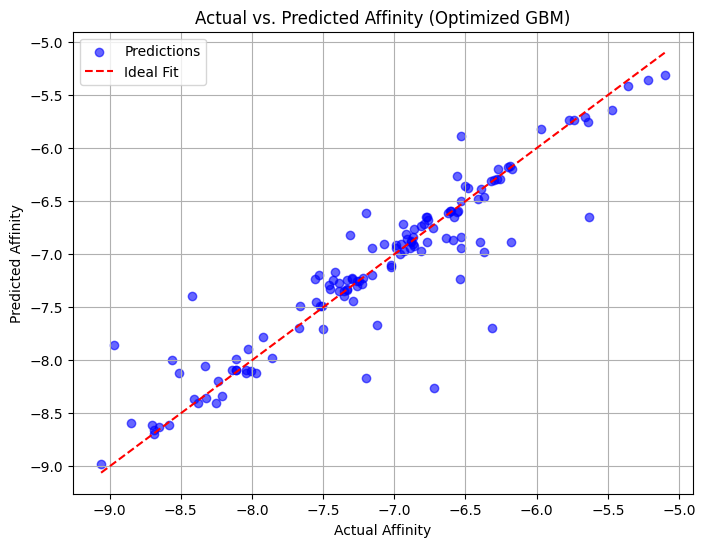

[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.4s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=500; total time=   2.1s
[CV] END ..learning_rate=0.01, max_depth=5, n_estimators=200; total time=   1.3s
[CV] END .learning_rate=0.01, max_depth=10, n_estimators=100; total time=   1.3s
[CV] END .learning_rate=0.01, max_depth=10, n_estimators=100; total time=   1.3s
[CV] END .learning_rate=0.01, max_depth=10, n_estimators=200; total time=   2.6s
[CV] END ...learning_rate=0.1, max_depth=3, n_estimators=100; total time=   0.4s
[CV] END ...learning_rate=0.1, max_depth=3, n_estimators=200; total time=   1.1s
[CV] END ...learning_rate=0.1, max_depth=3, n_estimators=500; total time=   4.8s
[CV] END ...learning_rate=0.1, max_depth=3, n_estimators=500; total time=   2.4s
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=500; total time=   4.0s
[CV] END ..learning_rate=0.1, max_depth=10, n_estimators=500; total time=   6.5s
[CV] END ...learning_rate=0.

In [ ]:
print("✅ GBM Model Training Complete!")
print(metrics_text)
# 📈 Visualization
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, color="blue", alpha=0.6, label="Predictions")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color="red", linestyle="dashed", label="Ideal Fit")
plt.xlabel("Actual Affinity")
plt.ylabel("Predicted Affinity")
plt.title("Actual vs. Predicted Affinity (Optimized GBM)")
plt.legend()
plt.grid()
plt.savefig("GBM_PIC50_Plot_Optimized_97_final_lit_10fold.png", dpi=300)
plt.show()

In [ ]:
#### Corrected New Below####

In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit.ML.Descriptors.MoleculeDescriptors import MolecularDescriptorCalculator
from rdkit.Chem import Descriptors

# Load the dataset
input_file = "processed_features_extended_corrected.csv"  # Replace with your file path
output_file = "dataset_with_rdkit_features_corrected.csv"

# Load the dataset
data = pd.read_csv(input_file)

# Extract the SMILES column (5th column)
smiles_list = data.iloc[:, 4]  # Assuming SMILES is in the 5th column

# Define RDKit descriptors
descriptor_names = [desc[0] for desc in Descriptors.descList]
calculator = MolecularDescriptorCalculator(descriptor_names)

# Function to calculate RDKit descriptors
def calculate_rdkit_features(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return [None] * len(descriptor_names)
        return calculator.CalcDescriptors(mol)
    except Exception as e:
        print(f"Error calculating descriptors for SMILES: {smiles}, Error: {e}")
        return [None] * len(descriptor_names)

# Calculate features for each SMILES
rdkit_features = []
for smiles in smiles_list:
    rdkit_features.append(calculate_rdkit_features(smiles))

# Create a DataFrame with the RDKit features
rdkit_features_df = pd.DataFrame(rdkit_features, columns=descriptor_names)

# Append RDKit features to the original dataset
data_with_features = pd.concat([data, rdkit_features_df], axis=1)

# Save the updated dataset to a new CSV file
data_with_features.to_csv(output_file, index=False)

print(f"RDKit features added and saved to {output_file}")

RDKit features added and saved to dataset_with_rdkit_features_corrected.csv


In [ ]:
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

# Load the data
input_file = "Only_features_corrected.csv"  # Replace with your file path
output_file = "VT_reduced_corrected.csv"

data = pd.read_csv(input_file)
#file_names = data["File_name"]

# Drop the "FileName" column (assuming it's the first column)
descriptor_data = data.iloc[:, 1:]

# Use VarianceThreshold to filter low-variance descriptors
selector = VarianceThreshold(threshold=0.01)  # Adjust threshold as needed
selector.fit(descriptor_data)

# Get the indices of descriptors that pass the threshold
selected_indices = selector.get_support(indices=True)

# Select descriptors based on variance threshold
filtered_data = descriptor_data.iloc[:, selected_indices]

# Further reduce to the top 30 descriptors (e.g., by variance or domain knowledge)
#top_30_descriptors = filtered_data.iloc[:, :30]  # Adjust selection logic as needed

In [ ]:
filtered_data

,instability_index,isoelectric_point,gravy,molecular_weight,mol_weight,num_h_donors,num_h_acceptors,tpsa,logp,num_rotatable_bonds,...,fr_Ar_NH,fr_NH1,fr_NH2,fr_Nhpyrrole,fr_alkyl_halide,fr_bicyclic,fr_ether,fr_halogen,fr_phos_acid,fr_phos_ester
0,45.387820,8.174220,-0.417200,57382.1683,412.225,8,14,230.69,-6.1268,6,...,0,1,0,0,0,0,1,0,0,0
1,44.963719,8.797501,-0.442762,52145.3884,412.225,8,14,230.69,-6.1268,6,...,0,1,0,0,0,0,1,0,0,0
2,30.559716,6.537359,-0.098578,47183.2095,574.366,11,19,309.84,-8.3026,9,...,0,1,0,0,0,0,2,0,0,0
3,48.307771,5.800783,-0.188691,70557.8419,412.225,8,14,230.69,-6.1268,6,...,0,1,0,0,0,0,1,0,0,0
4,48.675543,5.800783,-0.182496,70342.6354,412.225,8,14,230.69,-6.1268,6,...,0,1,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645,39.139592,6.172737,-0.252245,27106.6604,590.365,12,20,330.07,-8.9842,9,...,0,1,0,0,0,0,2,0,0,0
646,35.486347,8.677654,-0.369742,31362.6777,566.300,9,17,316.61,-4.7100,9,...,1,1,0,1,0,0,2,0,2,2
647,35.486347,8.677654,-0.369742,31362.6777,566.300,9,17,316.61,-4.7100,9,...,1,1,0,1,0,0,2,0,2,2
648,40.986550,8.488697,-0.402924,39671.7405,617.435,12,20,321.87,-8.3670,11,...,0,2,0,0,0,0,2,0,0,0


In [ ]:
data

,seq_length,aromaticity,instability_index,isoelectric_point,gravy,molecular_weight,A,C,D,E,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,500,0.090000,45.387820,8.174220,-0.417200,57382.1683,0.036000,0.026000,0.060000,0.064000,...,0,0,0,0,0,0,0,0,0,0
1,449,0.091314,44.963719,8.797501,-0.442762,52145.3884,0.033408,0.026726,0.060134,0.060134,...,0,0,0,0,0,0,0,0,0,0
2,422,0.087678,30.559716,6.537359,-0.098578,47183.2095,0.063981,0.009479,0.052133,0.068720,...,0,0,0,0,0,0,0,0,0,0
3,619,0.101777,48.307771,5.800783,-0.188691,70557.8419,0.064620,0.019386,0.059774,0.059774,...,0,0,0,0,0,0,0,0,0,0
4,617,0.102107,48.675543,5.800783,-0.182496,70342.6354,0.064830,0.019449,0.059968,0.059968,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645,245,0.073469,39.139592,6.172737,-0.252245,27106.6604,0.069388,0.004082,0.053061,0.065306,...,0,0,0,0,0,0,0,0,0,0
646,271,0.121771,35.486347,8.677654,-0.369742,31362.6777,0.036900,0.018450,0.059041,0.040590,...,0,0,0,0,0,0,0,0,0,0
647,271,0.121771,35.486347,8.677654,-0.369742,31362.6777,0.036900,0.018450,0.059041,0.040590,...,0,0,0,0,0,0,0,0,0,0
648,342,0.134503,40.986550,8.488697,-0.402924,39671.7405,0.078947,0.014620,0.070175,0.049708,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
filtered_data.to_csv(output_file, index=False)

                   instability_index  isoelectric_point     gravy  \
instability_index           1.000000          -0.166583 -0.000161   
isoelectric_point          -0.166583           1.000000 -0.052891   
gravy                      -0.000161          -0.052891  1.000000   
molecular_weight            0.063687          -0.061124 -0.014048   
mol_weight                 -0.093534           0.075507 -0.115785   
...                              ...                ...       ...   
fr_bicyclic                -0.070130          -0.091115 -0.205342   
fr_ether                   -0.107905           0.082147 -0.078180   
fr_halogen                  0.006304           0.019718 -0.074273   
fr_phos_acid                0.113537           0.108548 -0.063293   
fr_phos_ester               0.113537           0.108548 -0.063293   

                   molecular_weight  mol_weight  num_h_donors  \
instability_index          0.063687   -0.093534     -0.157806   
isoelectric_point         -0.061124    0.

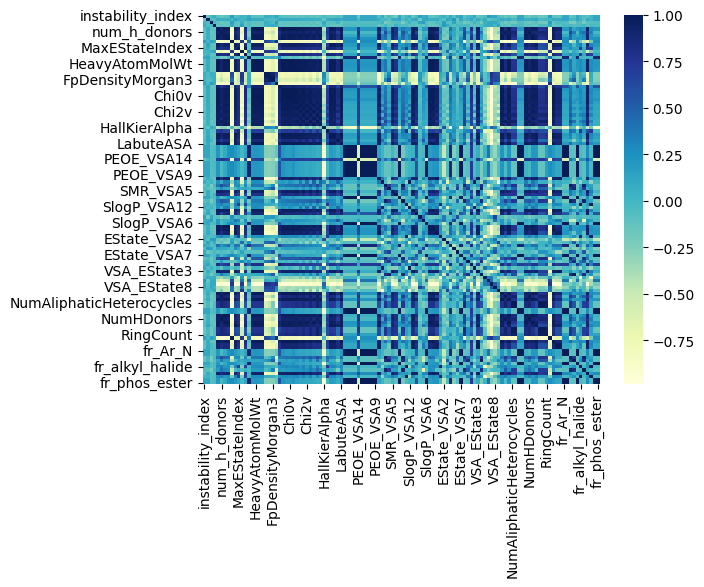

In [ ]:
# Import modules
import matplotlib.pyplot as mp
import pandas as pd
import seaborn as sb

# Import file with data
data = pd.read_csv('VT_reduced_corrected_wn.csv')

# Print data that will be plotted
# Columns shown here are selected by corr() since
# they are ideal for the plot
print(data.corr(numeric_only=False))

# Plotting correlation heatmap
dataplot = sb.heatmap(data.corr(numeric_only=True), cmap="YlGnBu", annot=False)

# Displaying heatmap
mp.show()

Saved 23 features in 'output_Selected_Final.csv'


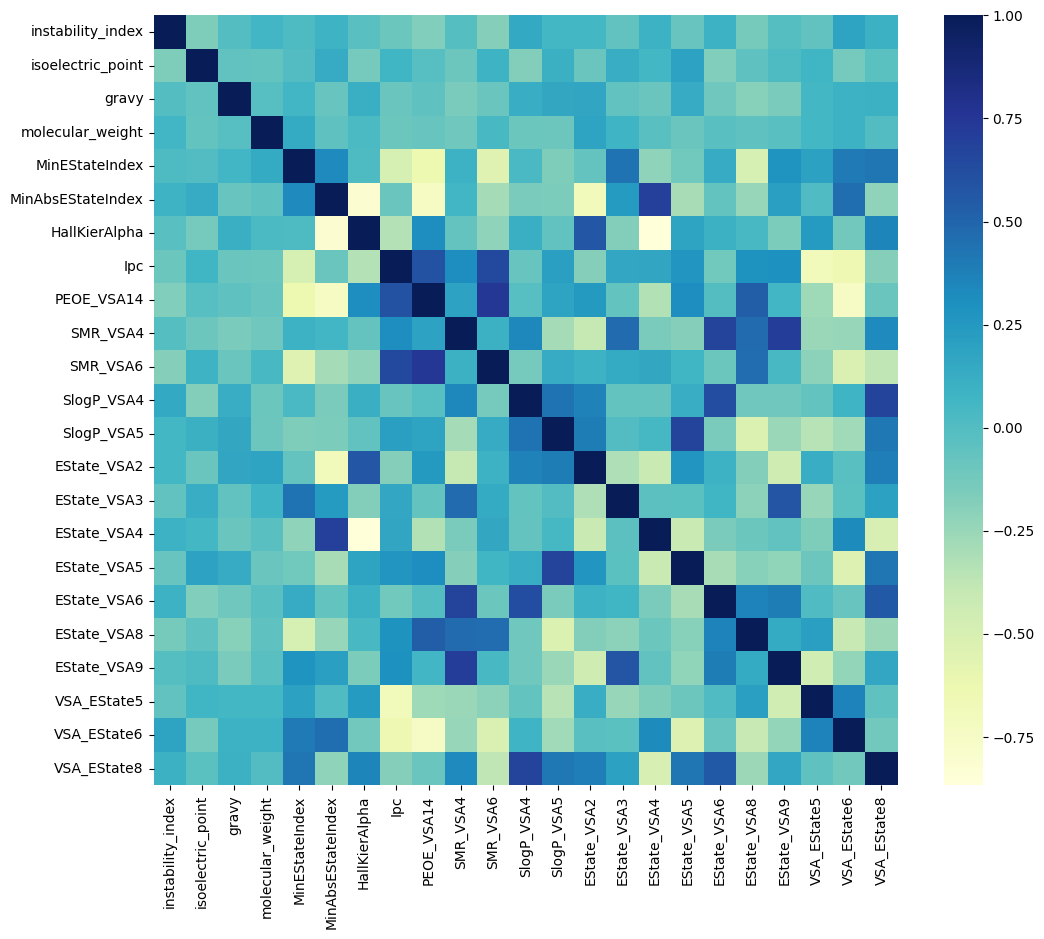

In [ ]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as mp

# 📂 Load CSV file
data = pd.read_csv("VT_reduced_corrected_wn.csv")

# 🔍 Compute the correlation matrix
corr_matrix = data.corr(numeric_only=True)

# 🎯 Define a correlation threshold
threshold = 0.9  # Adjust if needed

# 📌 Identify and remove highly correlated features
to_drop = set()
corr_pairs = corr_matrix.abs().unstack().sort_values(ascending=False)

for (feature1, feature2), value in corr_pairs.items():
    if feature1 != feature2 and value >= threshold:
        if feature2 not in to_drop:
            to_drop.add(feature2)  # Remove one of the correlated features

# ✂ Filter out the selected features
selected_features = [col for col in data.columns if col not in to_drop]
filtered_data = data[selected_features]

# 💾 Save the final selected features
filtered_data.to_csv('output_Selected_Final_1305.csv', index=False)
print(f"Saved {len(selected_features)} features in 'output_Selected_Final.csv'")

# 🎨 Plot correlation heatmap for filtered data
mp.figure(figsize=(12, 10))
sb.heatmap(filtered_data.corr(numeric_only=True), cmap="YlGnBu", annot=False)

# 📊 Display heatmap
mp.show()

In [ ]:
filtered_data

,instability_index,isoelectric_point,gravy,molecular_weight,MinEStateIndex,MinAbsEStateIndex,HallKierAlpha,Ipc,PEOE_VSA14,SMR_VSA4,...,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA8,EState_VSA9,VSA_EState5,VSA_EState6,VSA_EState8
0,45.387820,8.174220,-0.417200,57382.1683,-5.557602,0.111149,0.30,1.812587e+05,141.713542,0.0,...,12.965578,0.0,0.00000,4.899910,0.0,14.151167,14.523686,0.0,0.000000,-0.702921
1,44.963719,8.797501,-0.442762,52145.3884,-5.557602,0.111149,0.30,1.812587e+05,141.713542,0.0,...,12.965578,0.0,0.00000,4.899910,0.0,14.151167,14.523686,0.0,0.000000,-0.702921
2,30.559716,6.537359,-0.098578,47183.2095,-5.886254,0.046445,0.10,4.178593e+07,203.819624,0.0,...,12.965578,0.0,4.89991,0.000000,0.0,18.674914,14.580253,0.0,0.000000,-1.772023
3,48.307771,5.800783,-0.188691,70557.8419,-5.557602,0.111149,0.30,1.812587e+05,141.713542,0.0,...,12.965578,0.0,0.00000,4.899910,0.0,14.151167,14.523686,0.0,0.000000,-0.702921
4,48.675543,5.800783,-0.182496,70342.6354,-5.557602,0.111149,0.30,1.812587e+05,141.713542,0.0,...,12.965578,0.0,0.00000,4.899910,0.0,14.151167,14.523686,0.0,0.000000,-0.702921
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645,39.139592,6.172737,-0.252245,27106.6604,-5.989901,0.029608,0.06,5.869714e+07,208.609296,0.0,...,12.965578,0.0,4.89991,0.000000,0.0,18.674914,9.473726,0.0,0.000000,-0.944939
646,35.486347,8.677654,-0.369742,31362.6777,-5.592374,0.722789,-1.38,4.178593e+07,21.335138,0.0,...,0.000000,0.0,16.83031,0.000000,0.0,13.358126,14.580253,0.0,0.928242,-1.925198
647,35.486347,8.677654,-0.369742,31362.6777,-5.592374,0.722789,-1.38,4.178593e+07,21.335138,0.0,...,0.000000,0.0,16.83031,0.000000,0.0,13.358126,14.580253,0.0,0.928242,-1.925198
648,40.986550,8.488697,-0.402924,39671.7405,-5.898922,0.045512,0.06,1.546826e+08,222.225925,0.0,...,12.965578,0.0,0.00000,11.823647,0.0,19.467956,13.997473,0.0,-1.566757,-0.542920


[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=4. Current value: min_data_in_leaf=4
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=4. Current value: min_data_in_leaf=4
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000629 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1676
[LightGBM] [Info] Number of data points in the train set: 390, number of used features: 116
[LightGBM] [Info] Start training from score -7.205590


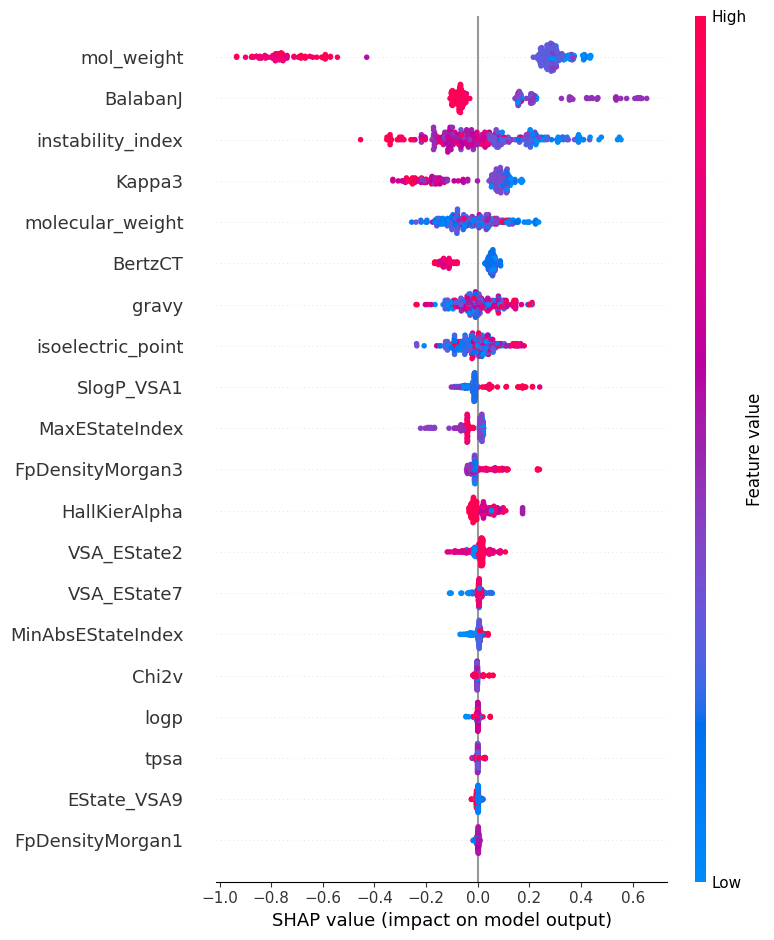

In [ ]:
import shap
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("VT_reduced_corrected.csv")  # 77 features + activity column

# Define features and target
X = df.drop(columns=["Protein_name", "Binding_affinity"])  # Exclude non-numeric columns
y = df["Binding_affinity"]

# Split into train and validation sets (40% test size as per your previous setup)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.4, random_state=42)

# Train LightGBM model
lgbm = lgb.LGBMRegressor(n_estimators=200, max_depth=20, min_samples_leaf=4, min_samples_split=2, random_state=42)
lgbm.fit(X_train, y_train)

# Compute SHAP values
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer(X_val)

# SHAP Summary Plot (Shows feature importance)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_val)

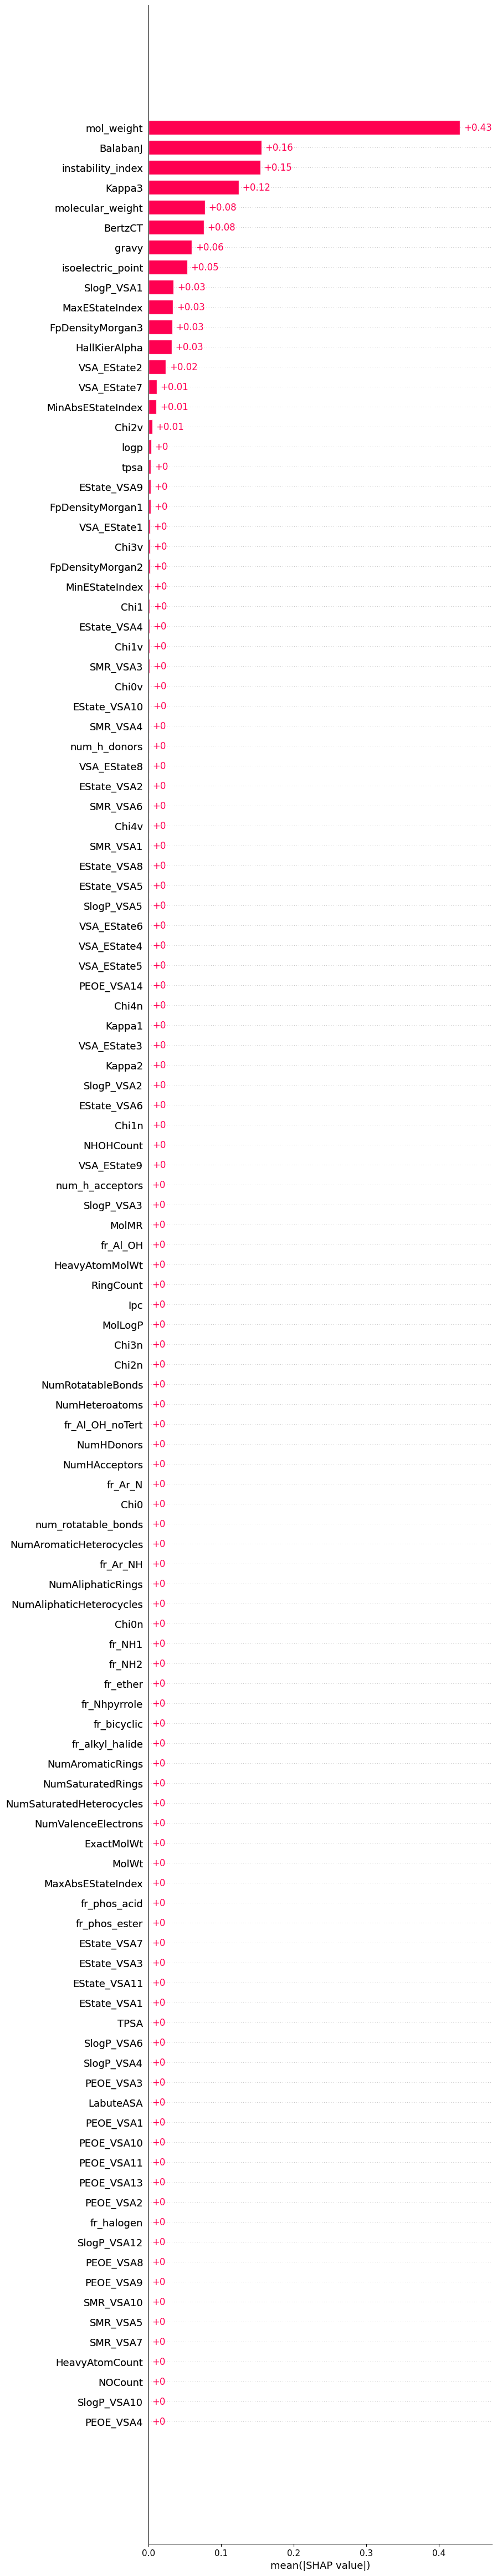

In [ ]:
shap.plots.bar(shap_values, max_display=116)  # Display all 80 features

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Load dataset
file_path = "output_Selected_Final_1305.csv"  # Update with your file path
data = pd.read_csv(file_path)

# Define features and target
X = data.drop(columns=["Protein_name", "Binding_affinity"])  # Exclude non-numeric columns
y = data["Binding_affinity"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model to get feature importances
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Get feature importances
feature_importances = model.feature_importances_
feature_names = X.columns

# Rank features by importance
sorted_indices = np.argsort(feature_importances)[::-1]
sorted_features = feature_names[sorted_indices]
sorted_importances = feature_importances[sorted_indices]

# Track R² scores as features are added
r2_scores = []
selected_features = []
best_r2 = 0
best_feature_count = 0

for i in range(1, len(sorted_features) + 1):
    # Use top i features
    X_train_subset = X_train[sorted_features[:i]]
    X_test_subset = X_test[sorted_features[:i]]

    # Train model with selected features
    model.fit(X_train_subset, y_train)
    y_pred = model.predict(X_test_subset)

    # Compute R² score
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)
    selected_features.append(sorted_features[:i])

    # Store best feature count
    if r2 > best_r2:
        best_r2 = r2
        best_feature_count = i


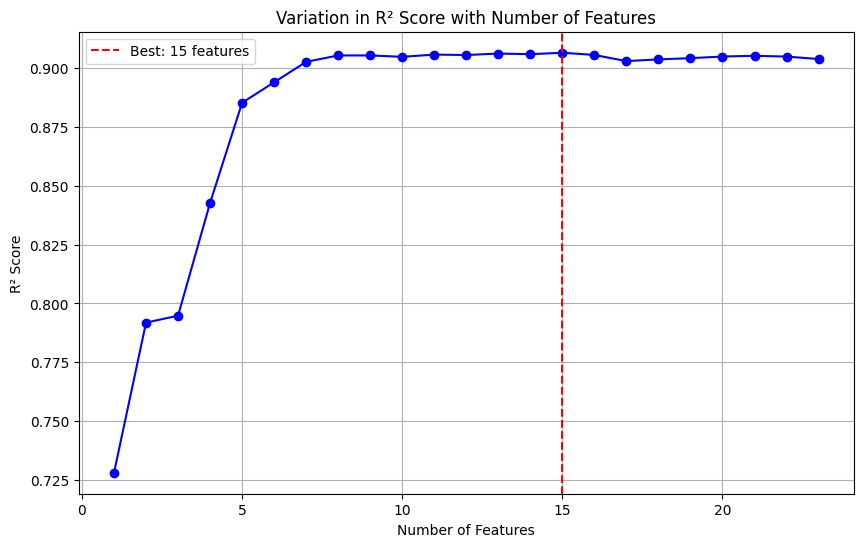

In [ ]:
# Plot R² score vs. number of features
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(sorted_features) + 1), r2_scores, marker="o", linestyle="-", color="b")
plt.axvline(x=best_feature_count, color="r", linestyle="--", label=f"Best: {best_feature_count} features")
plt.xlabel("Number of Features")
plt.ylabel("R² Score")
plt.title("Variation in R² Score with Number of Features")
plt.legend()
plt.grid()
plt.savefig("feature_selection_r2_plot3_134.png", dpi=300)
plt.show()



In [ ]:
#Save the best selected features
optimal_features = selected_features[best_feature_count - 1]  # Features at best R²
selected_data = data[["Protein_name", "Binding_affinity"] + list(optimal_features)]
selected_data.to_csv("15_features.csv", index=False)

print(f"Best R² Score: {best_r2:.4f} achieved with {best_feature_count} features.")
print(f"Selected features saved as 'top_selected_features.csv'.")

Best R² Score: 0.9063 achieved with 15 features.
Selected features saved as 'top_selected_features.csv'.


🔍 Performing Randomized Search...
🔍 Performing Grid Search for Fine-tuning...


/home/sudipta/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/sudipta/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/sudipta/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/sudipta/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/sudipta/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined wit

✅ Model training and validation complete!
R² Training: 0.9752
R² Test: 0.9047
MAE Training: 0.0893
MAE Test: 0.1705
RMSE Training: 0.1336
RMSE Test: 0.2593
Standard Deviation Training: 0.1336
Standard Deviation Test: 0.2586
Cross-validation R² (10-Fold): 0.8185
Leave-One-Out R²: nan
Jackknife R²: 0.8268



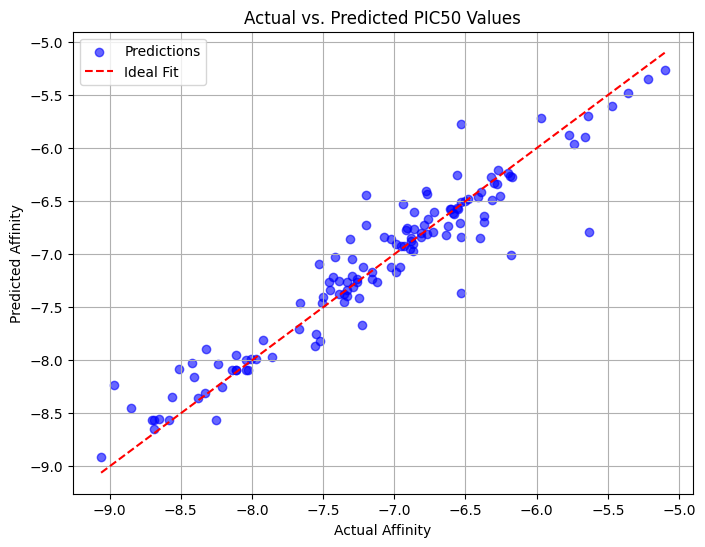

In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, cross_val_score, LeaveOneOut
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1️⃣ Load dataset
file_path = "15_features.csv"  # Replace with actual dataset path
data = pd.read_csv(file_path)

# 2️⃣ Define features and target
X = data.drop(columns=["Protein_name", "Binding_affinity"])  # Drop non-numeric columns
y = data["Binding_affinity"]

# 3️⃣ Split dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4️⃣ Define Random Forest model
rf_model = RandomForestRegressor(random_state=42)

# 5️⃣ Define hyperparameter search space
param_grid = {
    "n_estimators": [100, 200, 500],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# 6️⃣ Hyperparameter tuning
print("🔍 Performing Randomized Search...")
random_search = RandomizedSearchCV(rf_model, param_grid, n_iter=10, cv=10, scoring="r2", n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)

print("🔍 Performing Grid Search for Fine-tuning...")
grid_search = GridSearchCV(rf_model, param_grid, cv=10, scoring="r2", n_jobs=-1)
grid_search.fit(X_train, y_train)

# Select the best model
best_rf_model = grid_search.best_estimator_

# 7️⃣ Evaluate model on Test Set
y_pred_train = best_rf_model.predict(X_train)
y_pred_test = best_rf_model.predict(X_test)

# Calculate metrics
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

train_std = np.std(y_train - y_pred_train)
test_std = np.std(y_test - y_pred_test)

# 8️⃣ Cross-validation (10-Fold CV)
cv_scores = cross_val_score(best_rf_model, X_train, y_train, cv=10, scoring="r2")
cv_r2_mean = cv_scores.mean()

# 9️⃣ Leave-One-Out Cross-Validation (LOO)
loo = LeaveOneOut()
loo_scores = cross_val_score(best_rf_model, X_train, y_train, cv=loo, scoring="r2")
loo_r2_mean = loo_scores.mean()

# 🔟 Jackknife (Resampling Method)
jackknife_scores = []
for i in range(len(y_train)):
    X_jackknife = np.delete(X_train.to_numpy(), i, axis=0)
    y_jackknife = np.delete(y_train.to_numpy(), i)

    model = RandomForestRegressor(random_state=42)
    model.fit(X_jackknife, y_jackknife)
    y_pred_jackknife = model.predict(X_train.iloc[[i]])[0]
    jackknife_scores.append(y_train.iloc[i] - y_pred_jackknife)

jackknife_r2 = 1 - (np.var(jackknife_scores) / np.var(y_train))

# 📊 Save Results
metrics_text = (
    f"R² Training: {train_r2:.4f}\n"
    f"R² Test: {test_r2:.4f}\n"
    f"MAE Training: {train_mae:.4f}\n"
    f"MAE Test: {test_mae:.4f}\n"
    f"RMSE Training: {train_rmse:.4f}\n"
    f"RMSE Test: {test_rmse:.4f}\n"
    f"Standard Deviation Training: {train_std:.4f}\n"
    f"Standard Deviation Test: {test_std:.4f}\n"
    f"Cross-validation R² (10-Fold): {cv_r2_mean:.4f}\n"
    f"Leave-One-Out R²: {loo_r2_mean:.4f}\n"
    f"Jackknife R²: {jackknife_r2:.4f}\n"
)

with open("metrics_RF_15.txt", "w") as file:
    file.write(metrics_text)

# 📈 Save test predictions
test_results = pd.DataFrame({"Actual_Affinity": y_test, "Predicted_Affinity": y_pred_test})
test_results.to_csv("test_set_predictions_RF_15_final.csv", index=False)

# 💾 Save model
joblib.dump(best_rf_model, "random_forest_model_15_final.pkl")

print("✅ Model training and validation complete!")
print(metrics_text)

# 📊 Visualization
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, color="blue", alpha=0.6, label="Predictions")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color="red", linestyle="dashed", label="Ideal Fit")
plt.xlabel("Actual Affinity")
plt.ylabel("Predicted Affinity")
plt.title("Actual vs. Predicted PIC50 Values")
plt.legend()
plt.grid()
plt.savefig("RF_PIC50_Plot_15_final.png", dpi=300)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import joblib
import time
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import r2_score

# Load dataset
file_path = "15_features.csv"
data = pd.read_csv(file_path)

# Define features and target
X = data.drop(columns=["Protein_name", "Binding_affinity"])
y = data["Binding_affinity"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define GBR model
gbr_model = GradientBoostingRegressor(random_state=42)

# Hyperparameter search space
param_grid = {
    "n_estimators": [100, 200, 500],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, 10]
}

# Progress tracking
print("🔍 Performing Grid Search for GBR...")
start_time = time.time()

# Grid Search
grid_search = GridSearchCV(gbr_model, param_grid, cv=10, scoring="r2", n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# Best GBR model
best_gbr_model = grid_search.best_estimator_
print(f"✅ Best GBR Model Found: {best_gbr_model}")

# Predictions
y_pred_train = best_gbr_model.predict(X_train)
y_pred_test = best_gbr_model.predict(X_test)

# Model Evaluation
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

# 10-Fold Cross-Validation
print("🔄 Running 10-Fold Cross-Validation...")
cv_scores = cross_val_score(best_gbr_model, X_train, y_train, cv=10, scoring="r2", n_jobs=-1)
cv_r2_mean = np.mean(cv_scores)

print(f"✅ 10-Fold Cross-Validation R²: {cv_r2_mean:.4f}")

# Save model
joblib.dump(best_gbr_model, "gbr_model_10fold_final_15features.pkl")
print("✅ GBR Model Saved!")

# Save Predictions
test_results = pd.DataFrame({"Actual_Aiffinity": y_test, "Predicted_Affinity": y_pred_test})
test_results.to_csv("test_set_predictions_gbr_10fold_final_15features.csv", index=False)

# Save Metrics
metrics_text = (
    f"Training R²: {train_r2}\n"
    f"Test R²: {test_r2}\n"
    f"10-Fold CV R²: {cv_r2_mean}\n"
    f"Time Taken: {time.time() - start_time:.2f} seconds\n"
)
with open("metrics_gbr_10fold_final_15features.txt", "w") as file:
    file.write(metrics_text)

print("✅ GBR Model Training Complete!")
print(metrics_text)

🔍 Performing Grid Search for GBR...
Fitting 10 folds for each of 27 candidates, totalling 270 fits
✅ Best GBR Model Found: GradientBoostingRegressor(learning_rate=0.2, max_depth=5, random_state=42)
🔄 Running 10-Fold Cross-Validation...
✅ 10-Fold Cross-Validation R²: 0.8190
✅ GBR Model Saved!
✅ GBR Model Training Complete!
Training R²: 0.9970644843001343
Test R²: 0.882146256998329
10-Fold CV R²: 0.8189947585402889
Time Taken: 15.27 seconds



✅ GBM Model Training Complete!
Training R²: 0.9970644843001343
Test R²: 0.882146256998329
10-Fold CV R²: 0.8189947585402889
Time Taken: 15.27 seconds



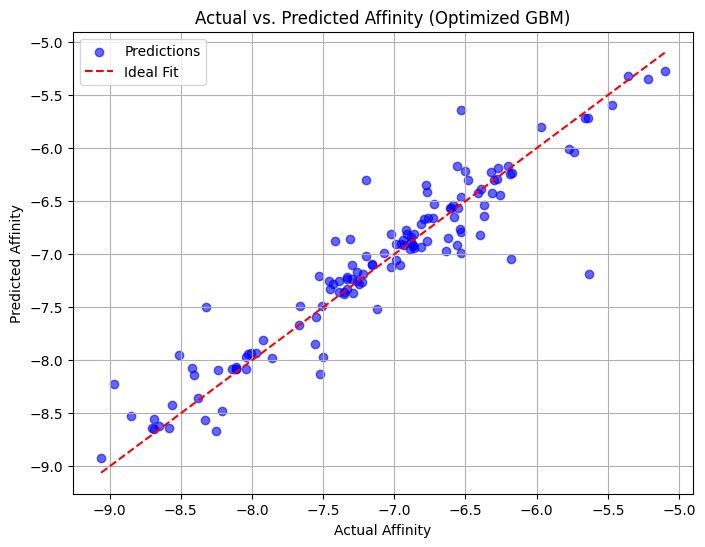

In [ ]:
print("✅ GBM Model Training Complete!")
print(metrics_text)
# 📈 Visualization
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, color="blue", alpha=0.6, label="Predictions")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color="red", linestyle="dashed", label="Ideal Fit")
plt.xlabel("Actual Affinity")
plt.ylabel("Predicted Affinity")
plt.title("Actual vs. Predicted Affinity (Optimized GBM)")
plt.legend()
plt.grid()
plt.savefig("GBM_PIC50_Plot_Optimized_97_final_lit_10fold_15features.png", dpi=300)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, cross_val_score
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Load dataset
file_path = "15_features.csv"
data = pd.read_csv(file_path)

# Define features and target
X = data.drop(columns=["Protein_name", "Binding_affinity"])
y = data["Binding_affinity"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define SVR model
svr_model = SVR()

# Define hyperparameter search space
param_grid = {
    "C": [0.1, 1, 10, 100],
    "epsilon": [0.01, 0.1, 0.5, 1],
    "kernel": ["linear", "rbf"]
}

# Hyperparameter tuning
print("🔍 Performing Grid Search for SVR...")
grid_search = GridSearchCV(svr_model, param_grid, cv=10, scoring="r2", n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best SVR model
best_svr_model = grid_search.best_estimator_

# Predictions
y_pred_train = best_svr_model.predict(X_train)
y_pred_test = best_svr_model.predict(X_test)

# Metrics
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

# Cross-validation (10-fold)
cv_scores = cross_val_score(best_svr_model, X_train, y_train, cv=10, scoring="r2")
cv_r2_mean = cv_scores.mean()

# Jackknife Resampling
#jackknife_scores = []
  #  for i in range(len(y_train)):
    # X_jackknife = np.delete(X_train.to_numpy(), i, axis=0)
    # y_jackknife = np.delete(y_train.to_numpy(), i)

   #  model = SVR(C=best_svr_model.C, epsilon=best_svr_model.epsilon, kernel=best_svr_model.kernel)
    # model.fit(X_jackknife, y_jackknife)

   #  y_pred_jackknife = model.predict(X_train.iloc[[i]])[0]
   #  jackknife_scores.append(y_train.iloc[i] - y_pred_jackknife)

    # jackknife_r2 = 1 - (np.var(jackknife_scores) / np.var(y_train))

# Save model
joblib.dump(best_svr_model, "svr_model97_final_15features.pkl")
print(f"✅ SVR Model Saved! Jackknife R²: {jackknife_r2:.4f}")

# Save Predictions
test_results = pd.DataFrame({"Actual_Affinity": y_test, "Predicted_Affinity": y_pred_test})
test_results.to_csv("test_set_predictions_svr97_final_15features.csv", index=False)

# Save Metrics
metrics_text = (
    f"R2 Training: {train_r2}\n"
    f"R2 Test: {test_r2}\n"
    f"MAE Training: {train_mae}\n"
    f"MAE Test: {test_mae}\n"
    f"RMSE Training: {train_rmse}\n"
    f"RMSE Test: {test_rmse}\n"
    f"STD Training: {train_std}\n"
    f"STD Test: {test_std}\n"
    f"10-Fold CV R²: {cv_r2_mean}\n"
    #f"Leave-One-Out R²: {loo_r2_mean}\n"
)

with open("metrics_svr97_final_15features.txt", "w") as file:
    file.write(metrics_text)

print("✅ Support Vector Regressor model saved!")
print(metrics_text)

# 📊 Visualization
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, color="blue", alpha=0.6, label="Predictions")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color="red", linestyle="dashed", label="Ideal Fit")
plt.xlabel("Actual Affinity")
plt.ylabel("Predicted Affinity")
plt.title("Actual vs. Predicted Affinity Values")
plt.legend()
plt.grid()
plt.savefig("SVR_PIC50_Plot_97_final_rerun_15features.png", dpi=300)
plt.show()

🔍 Performing Grid Search for SVR...


In [ ]:
import pickle
model1=pickle.load(open('gbr_model_10fold_final_15features.pkl','rb'))
model2=pickle.load(open('random_forest_model_15_final.pkl','rb'))
model1

array(['Ipc', 'instability_index', 'MinEStateIndex', 'molecular_weight',
       'gravy', 'isoelectric_point', 'HallKierAlpha', 'EState_VSA8',
       'VSA_EState6', 'EState_VSA9', 'SMR_VSA6', 'EState_VSA5',
       'SlogP_VSA5', 'PEOE_VSA14', 'MinAbsEStateIndex'], dtype=object)

In [ ]:
from sklearn.metrics import RocCurveDisplay
g1 = RocCurveDisplay.from_estimator(model1, X_test, y_test, name = 'RF_2Class', color = 'red')

#xgb = RocCurveDisplay.from_estimator(grid_search_xgb, X_test, y_test, ax=mlp.ax_,name = 'XGB' )
g2 = RocCurveDisplay.from_estimator(model2, X_test, y_test, ax=g1.ax_,name = '*RF_2Class', color = 'blue' )

NameError: name 'X_test' is not defined

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from sklearn.metrics import r2_score

# Load your trained Random Forest model
with open('random_forest_model_44_final.pkl', 'rb') as f:
    model = pickle.load(f)

# Load or generate test data
# Replace this with your real test data
# Example placeholders:
X_test = ...  # Your feature matrix
y_actual = ...  # Actual affinity values (e.g., pIC50)

# Get predictions from the model
y_pred = model.predict(X_test)

# Compute Jackknife R² (standard R² on all data; for real jackknife, use resampling)
r2 = r2_score(y_actual, y_pred)

# Load Times New Roman Bold font
custom_font = font_manager.FontProperties(fname='timesbold.ttf')

# Create plot
plt.figure(figsize=(8, 6))
plt.scatter(y_actual, y_pred, color='blue', label='Predictions', alpha=0.7)
plt.plot([-9, -5], [-9, -5], 'r--', label='Ideal Fit')  # adjust range as needed

# Add R² to plot
plt.text(-8.8, -5.4, f'Jackknife R² = {r2:.2f}', fontsize=14,
         fontproperties=custom_font, color='black', bbox=dict(facecolor='white', edgecolor='black'))

# Labeling
plt.xlabel('Actual Affinity', fontsize=14, fontproperties=custom_font)
plt.ylabel('Predicted Affinity', fontsize=14, fontproperties=custom_font)
plt.title('Actual vs. Predicted PIC50 Values', fontsize=16, fontproperties=custom_font)
plt.legend(prop=custom_font, fontsize=12)

# Remove grid
plt.grid(False)

# Customize ticks
plt.xticks(fontsize=12, fontproperties=custom_font)
plt.yticks(fontsize=12, fontproperties=custom_font)

plt.tight_layout()
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'predict'

In [ ]:
import pickle
from sklearn.ensemble import RandomForestRegressor

# Load the model
with open('random_forest_model_44_final.pkl', 'rb') as f:
    model = pickle.load(f)

# Confirm it's a Random Forest model
print(type(model))  # Should say <class 'sklearn.ensemble._forest.RandomForestRegressor'>

<class 'numpy.ndarray'>


In [ ]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from sklearn.metrics import r2_score

# STEP 1: Load predicted values from file
with open('random_forest_model_44_final.pkl', 'rb') as f:
    y_pred = pickle.load(f)

# STEP 2: Load actual values from CSV
df = pd.read_csv('top_selected_features_44.csv')
y_actual = df['Binding_affinity'].values

# Ensure y_pred and y_actual have the same length
assert len(y_pred) == len(y_actual), "Length mismatch between predictions and actual values!"

# STEP 3: Compute R²
r2 = r2_score(y_actual, y_pred)

# STEP 4: Load custom Times New Roman Bold font
custom_font = font_manager.FontProperties(fname='timesbold.ttf')

# STEP 5: Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_actual, y_pred, color='blue', label='Predictions', alpha=0.7)
plt.plot([min(y_actual), max(y_actual)],
         [min(y_actual), max(y_actual)],
         'r--', label='Ideal Fit')

# Add R² text
plt.text(min(y_actual) + 0.2, max(y_actual) - 0.5,
         f'Jackknife R² = {r2:.2f}',
         fontsize=14, fontproperties=custom_font,
         bbox=dict(facecolor='white', edgecolor='black'))

# Axes and title
plt.xlabel('Actual Affinity', fontsize=14, fontproperties=custom_font)
plt.ylabel('Predicted Affinity', fontsize=14, fontproperties=custom_font)
plt.title('Actual vs. Predicted PIC50 Values', fontsize=16, fontproperties=custom_font)
plt.legend(prop=custom_font, fontsize=12)

# Remove grid and customize ticks
plt.grid(False)
plt.xticks(fontsize=12, fontproperties=custom_font)
plt.yticks(fontsize=12, fontproperties=custom_font)

plt.tight_layout()
plt.show()

AssertionError: Length mismatch between predictions and actual values!

In [ ]:
import pickle
import pandas as pd

# Load predicted values from the .pkl file
with open('random_forest_model_44_final.pkl', 'rb') as f:
    y_pred = pickle.load(f)

# Load actual values from CSV
df = pd.read_csv('top_selected_features_44.csv')
y_actual_full = df['Binding_affinity'].values

# Print lengths
print("📦 Length of predicted values (from model):", len(y_pred))
print("📊 Length of Binding_affinity column in CSV:", len(y_actual_full))

📦 Length of predicted values (from model): 44
📊 Length of Binding_affinity column in CSV: 650


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from sklearn.metrics import r2_score

# Step 1: Load the CSV file with actual and predicted values
df = pd.read_csv('test_set_predictions_RF_44_final.csv')

# Step 2: Extract values
y_actual = df['Actual_Affinity'].values
y_pred = df['Predicted_Affinity'].values

# Step 3: Compute R²
r2 = r2_score(y_actual, y_pred)

# Step 4: Load custom font
custom_font = font_manager.FontProperties(fname='timesbold.ttf')

# Step 5: Plotting
plt.figure(figsize=(8, 6))
plt.scatter(y_actual, y_pred, color='blue', label='Predictions', alpha=0.7)
plt.plot([min(y_actual), max(y_actual)],
         [min(y_actual), max(y_actual)],
         'r--', label='Ideal Fit')

# Add R² text to the plot
plt.text(min(y_actual) + 0.2, max(y_actual) - 0.5,
         f'Jackknife R² = {r2:.2f}',
         fontsize=14, fontproperties=custom_font,
         bbox=dict(facecolor='white', edgecolor='black'))

# Axis labels and title
plt.xlabel('Actual Affinity', fontsize=16, fontproperties=custom_font)
plt.ylabel('Predicted Affinity', fontsize=16, fontproperties=custom_font)
plt.legend(prop=custom_font, fontsize=20)

# Style adjustments
plt.grid(False)
plt.xticks(fontsize=12, fontproperties=custom_font)
plt.yticks(fontsize=12, fontproperties=custom_font)

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'test_set_predictions_RF_44_final.csv'